<div style="text-align: center; background: linear-gradient(135deg, #1a237e 0%, #283593 50%, #303f9f 100%); color: white; padding: 35px; border-radius: 12px; margin: 25px 0; font-family: 'Segoe UI', 'Arial', sans-serif; font-weight: 700; font-size: 2.1em; box-shadow: 0 6px 25px rgba(0,0,0,0.05); border-bottom: 4px solid #5c6bc0;">
Predicting 2024 Data Science Salaries Using Linear Regression</div>

<hr style="border: none; height: 2px; background: linear-gradient(to right, transparent, #5c6bc0, transparent); margin: 30px auto; width: 75%;">

<div style="background: #f8f9fa; color: #2c3e50; padding: 30px; border-radius: 12px; margin: 25px 0; border-left: 5px solid #5c6bc0; border-right: 5px solid #5c6bc0;box-shadow: 0 4px 15px rgba(0,0,0,0.08);">
<h3 style="color: #1a237e; margin-top: 0; text-align: center; font-weight: 600; font-size: 1.6em; margin-bottom: 15px;">
LEARNING OBJECTIVES
</h3>
<p style="color: #2c3e50; font-size: 1.15em; line-height: 1.7; text-align: justify; margin: 0 40px 5px; font-weight: 500;"> By the end of this assignment, you will be able to:</p>
  <ul style="font-size: 1.1em; line-height: 1.7; color: #2c3e50; margin: 0 60px 25px; font-weight: 500;">
    <li>Load and explore a real-world dataset</li>
    <li>Prepare data for linear regression (feature engineering, encoding, cleaning)</li>
    <li>Train a simple linear regression model using <code>scikit-learn</code></li>
    <li>Evaluate your model using metrics like R² and interpret the results</li>
    <li>Make predictions for future years (e.g., 2024)</li>
  </ul>

  <p style="color: #2c3e50; font-size: 1.15em; line-height: 1.7; text-align: justify; margin: 0 40px 25px; font-weight: 500;">
    <strong>Dataset:</strong>  
    You are given the file <code>Data Science Salary 2020 to 2023.csv</code>.
    <br><br>
    This dataset contains salary information for data professionals from 2020 to 2023, including:
  </p>
  
<ul style="font-size: 1.1em; line-height: 1.7; color: #2c3e50; margin: 0 60px 25px; font-weight: 500;">
  <li><strong>work_year:</strong> The year the salary was recorded</li>
  <li><strong>experience_level:</strong> EN (Entry), MI (Mid), SE (Senior), EX (Executive)</li>
  <li><strong>job_title:</strong> e.g., Data Scientist, Data Analyst, etc.</li>
  <li><strong>salary_in_usd:</strong> Salary converted to USD (this is your target variable)</li>
  <li><strong>Other useful columns:</strong> employment_type, company_location, company_size</li>
</ul>

<div style="background: white; padding: 25px; border-radius: 8px; margin: 20px 0; border: 1px solid #e0e0e0;">
<div style="display: flex; justify-content: space-evenly; align-items: center; text-align: center; width: 100%;">
    
<div style="width: 33%">
<strong style="color: #5c6bc0; display: block; margin-bottom: 8px; font-size: 1.1em;">Data Analyst</strong>
<span style="color: #1a237e; font-weight: 600; font-size: 1.1em;">Jomel Tomeo</span>
</div>

<div style="width: 33%">
<strong style="color: #5c6bc0; display: block; margin-bottom: 8px; font-size: 1.1em;">Report Date</strong>
<span style="color: #1a237e; font-weight: 600; font-size: 1.1em;">October 22, 2025</span>
</div>

<div style="width: 33%">
<strong style="color: #5c6bc0; display: block; margin-bottom: 8px; font-size: 1.1em;">Period Covered</strong>
<span style="color: #1a237e; font-weight: 600; font-size: 1.1em;">2020-2023</span>
</div>
</div>
</div>

<div style="text-align: center; margin-top: 30px;">
<span style="background: #5c6bc0; color: white; padding: 8px 20px; border-radius: 20px; font-weight: 600; font-size: 0.9em;">
  <strong>Goal:</strong> Predict average salaries for 2024 using linear regression.
</span>
</div>

</div>
</div>


<h3 style="text-align: center; background: #3f51b5; color: white; padding: 18px; border-radius: 8px; margin: 25px 0; font-family: 'Segoe UI', sans-serif; font-weight: 600; font-size: 1.4em;">
Part 1 : Setup and Data Loading 
</h3>

<h3>Initialization of Core Libraries</h3>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

<h3>Loading Dataset(s) into DataFrames </h3>
<ul>
    <li>DataFrame Identifier</li>
    <li>Dataset File Location</li>
</ul>

In [18]:
salaries = pd.read_csv("datasets\\Data Science Salary 2020 to 2023.csv")
salaries

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L
...,...,...,...,...,...,...,...,...,...
3756,2020,SE,FT,Principal Data Scientist,130000,EUR,148261,DE,M
3757,2020,SE,FT,Data Scientist,80000,EUR,91237,AT,S
3758,2020,SE,FT,Data Science Manager,190200,USD,190200,US,M
3759,2020,SE,FT,Machine Learning Engineer,40000,EUR,45618,HR,S


<h3 style="text-align: center; background: #3f51b5; color: white; padding: 18px; border-radius: 8px; margin: 25px 0; font-family: 'Segoe UI', sans-serif; font-weight: 600; font-size: 1.4em;">
Part 2: Explanatory Data Analysis (EDA)
</h3>

<h4>Answer the following questions:</h4>

<div style="background: white; padding: 25px; border-radius: 10px; margin: 25px 0; border: 1px solid #e0e0e0; box-shadow: 0 4px 15px rgba(0,0,0,0.05); overflow-x: auto;">
<table style="width: 100%; border-collapse: collapse; font-family: 'Segoe UI', sans-serif;">
<tr style="background: linear-gradient(135deg, #5c6bc0, #3949ab); color: white;">
<th style="padding: 15px; text-align: center; font-weight: 600; font-size: 1.1em; border: none; width: 50px;">#</th>
<th style="padding: 15px; text-align: left; font-weight: 600; font-size: 1.1em; border: none;">Analytical Question</th>
</tr>
<tr style="background: #f8f9fa;">
<td style="padding: 12px 8px; text-align: center; font-weight: 600; color: #5c6bc0; border-bottom: 1px solid #e0e0e0; width: 50px;">1</td>
<td style="padding: 12px 15px; border-bottom: 1px solid #e0e0e0;">How many unique job titles are there?
</td>
</tr>
<tr style="background: white;">
<td style="padding: 12px 8px; text-align: center; font-weight: 600; color: #5c6bc0; border-bottom: 1px solid #e0e0e0; width: 50px;">2</td>
<td style="padding: 12px 15px; border-bottom: 1px solid #e0e0e0;">What is the average salary (salary_in_usd) per work_year?
</td>
</tr>
<tr style="background: #f8f9fa;">
<td style="padding: 12px 8px; text-align: center; font-weight: 600; color: #5c6bc0; border-bottom: 1px solid #e0e0e0; width: 50px;">3</td>
<td style="padding: 12px 15px; border-bottom: 1px solid #e0e0e0;">Create a bar plot showing average salary by experience_level.
</td>
</tr>
</table>
</div>

<hr style="border: none; height: 2px; background: linear-gradient(to right, transparent, #5c6bc0, transparent); margin: 25px auto; width: 70%;">
<div style="background: #f8f9fa; color: #2c3e50; padding: 25px; border-radius: 10px; margin: 25px 0; border-left: 5px solid #5c6bc0; border-right: 5px solid #5c6bc0; box-shadow: 0 4px 12px rgba(0,0,0,0.06);">
<h2 style="color: #1a237e; margin: 0 0 10px 0; font-weight: 700; font-size: 1.8em; text-align: center;">
Question 1
</h2>
<h3 style="color: #2c3e50; margin: 0; font-weight: 600; font-size: 1.1em; text-align: center; line-height: 1.5;">
How many unique job titles are there?</h3>
</div>

In [19]:
unique_job_titles = salaries['job_title'].nunique()
print(f"Number of unique job titles: {unique_job_titles}")

Number of unique job titles: 93


<div style="background: #f5f9ff; color: #2c3e50; padding: 20px; border-radius: 10px; margin-top: 50px; border: 1px solid #e1ebff; position: relative;">
<div style="position: absolute; top: -10px; left: 20px; background: #5c6bc0; color: white; padding: 10px 18px; border-radius: 20px; font-size: 0.8em; font-weight: bold;">
ANALYSIS INSIGHT
</div>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
There are 93 different job titles in the company. "Data Scientist" and "Data Analyst" are no longer the only major roles.
The field has exploded into many highly specialized positions like Machine Learning Engineer, Applied Scientist, Data Quality Analyst, Principal Data Scientist and more.

</p>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
This proves that companies now need experts for very specific tasks.
</div>

<hr style="border: none; height: 2px; background: linear-gradient(to right, transparent, #5c6bc0, transparent); margin: 25px auto; width: 70%;">
<div style="background: #f8f9fa; color: #2c3e50; padding: 25px; border-radius: 10px; margin: 25px 0; border-left: 5px solid #5c6bc0; border-right: 5px solid #5c6bc0; box-shadow: 0 4px 12px rgba(0,0,0,0.06);">
<h2 style="color: #1a237e; margin: 0 0 10px 0; font-weight: 700; font-size: 1.8em; text-align: center;">
Question 2
</h2>
<h3 style="color: #2c3e50; margin: 0; font-weight: 600; font-size: 1.1em; text-align: center; line-height: 1.5;">
What is the average salary (salary_in_usd) per work_year?
</h3>
</div>

In [20]:
avg_salary_by_year = salaries.groupby('work_year')['salary_in_usd'].mean().round(2)
print("\nAverage salary per work year:")
print(avg_salary_by_year)


Average salary per work year:
work_year
2020     92302.63
2021     94087.21
2022    133379.51
2023    148954.56
Name: salary_in_usd, dtype: float64


<div style="background: #f5f9ff; color: #2c3e50; padding: 20px; border-radius: 10px; margin-top: 50px; border: 1px solid #e1ebff; position: relative;">
<div style="position: absolute; top: -10px; left: 20px; background: #5c6bc0; color: white; padding: 10px 18px; border-radius: 20px; font-size: 0.8em; font-weight: bold;">
ANALYSIS INSIGHT
</div>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
Data Science salaries are rising fast. The average pay jumped from 92,302 USD in 2020 to 148,954 USD in 2023. This is a 62% increase in just four years. Companies are paying much more to hire and keep data talents. 
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
We can confidently say that salaries increased in 2024 and 2025, and are expected to continue rising in the coming years.
</p>
</div>

<hr style="border: none; height: 2px; background: linear-gradient(to right, transparent, #5c6bc0, transparent); margin: 25px auto; width: 70%;">
<div style="background: #f8f9fa; color: #2c3e50; padding: 25px; border-radius: 10px; margin: 25px 0; border-left: 5px solid #5c6bc0; border-right: 5px solid #5c6bc0; box-shadow: 0 4px 12px rgba(0,0,0,0.06);">
<h2 style="color: #1a237e; margin: 0 0 10px 0; font-weight: 700; font-size: 1.8em; text-align: center;">
Question 3
</h2>
<h3 style="color: #2c3e50; margin: 0; font-weight: 600; font-size: 1.1em; text-align: center; line-height: 1.5;">
Create a bar plot showing average salary by experience_level.
</h3>
</div>

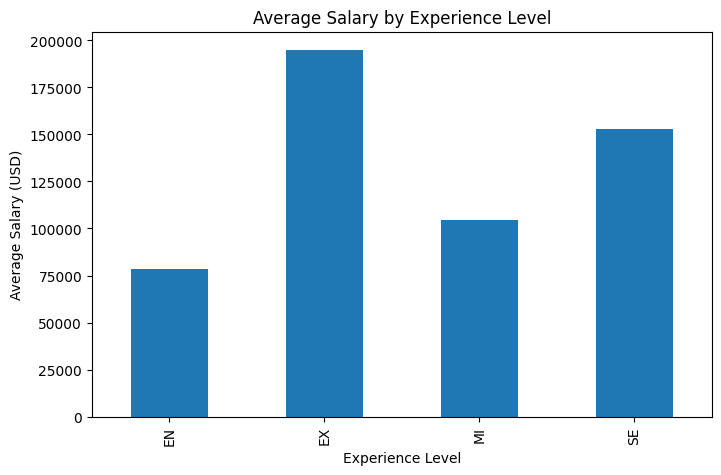

experience_level
EN     78546.28
EX    194930.93
MI    104544.86
SE    153062.47
Name: salary_in_usd, dtype: float64


In [16]:
avg_salary_by_exp = salaries.groupby('experience_level')['salary_in_usd'].mean().round(2)

plt.figure(figsize=(8, 5))
avg_salary_by_exp.plot(kind='bar')
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.show()
print(avg_salary_by_exp)

<div style="background: #f5f9ff; color: #2c3e50; padding: 20px; border-radius: 10px; margin-top: 50px; border: 1px solid #e1ebff; position: relative;">
<div style="position: absolute; top: -10px; left: 20px; background: #5c6bc0; color: white; padding: 10px 18px; border-radius: 20px; font-size: 0.8em; font-weight: bold;">
ANALYSIS INSIGHT
</div>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
Experience pays off dramatically in Data Science.
</p>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
The salary jumps with each level of experience: <strong>Entry-level (EN):</strong> 78,546 USD,  <strong>Mid-level (MI): </strong>104,545 USD, <strong>Senior-level (SE):</strong>  $153,062 USD, <strong> Executive-level (EX):</strong> 194,931 USD
</p>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
Executive-level professionals earn nearly 2.5 times more than entry-level roles. Advanced expertise and leadership in data fields are highly valued.
</p>
</div>

<h3 style="text-align: center; background: #3f51b5; color: white; padding: 18px; border-radius: 8px; margin: 25px 0; font-family: 'Segoe UI', sans-serif; font-weight: 600; font-size: 1.4em;">
Part 3 : Data Preprocessing for Linear Regression
</h3>

We will predict `salary_in_usd` using **only numerical or encoded categorical features**.

<h3> Steps : </h3>
<ol>
    <li>Select features: `work_year`, `experience_level`, and optionally `job_title` </li>
    <li>Encode categorical variables (`experience_level`) using `LabelEncoder` or `pd.get_dummies()`</li>
    <li>Define `X` (features) and `y` (target = `salary_in_usd`)</li>
</ol>


> **Important**: Do NOT include `salary`, `salary_currency`, or `salary_in_usd` in your features!

In [23]:
# Example: Encode experience_level
le = LabelEncoder()
salaries['experience_level_encoded'] = le.fit_transform(salaries['experience_level'])

# Choose your features - using work_year and experience_level only
features = ['work_year', 'experience_level_encoded']
X = salaries[features]
y = salaries['salary_in_usd']

# Optional: Add job_title with encoding (commented out to avoid too many categories)
salaries['job_title_encoded'] = LabelEncoder().fit_transform(salaries['job_title'])
features = ['work_year', 'experience_level_encoded', 'job_title_encoded']

X.head()

,work_year,experience_level_encoded
0,2023,0
1,2023,0
2,2023,0
3,2023,0
4,2023,0


<h3 style="text-align: center; background: #3f51b5; color: white; padding: 18px; border-radius: 8px; margin: 25px 0; font-family: 'Segoe UI', sans-serif; font-weight: 600; font-size: 1.4em;">
Part 4 : Train a Linear Regression Model
</h3>

In [24]:
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.15
RMSE: 59164.82


<h3 style="text-align: center; background: #3f51b5; color: white; padding: 18px; border-radius: 8px; margin: 25px 0; font-family: 'Segoe UI', sans-serif; font-weight: 600; font-size: 1.4em;">
Part 5 : Predict 2024 Salaries
</h3>

In [25]:
# Map experience levels to encoded values (check your LabelEncoder!)
# Example: EN=0, MI=1, SE=2, EX=3 (confirm with `le.classes_`)

future_data = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'experience_level_encoded': [0, 1, 2, 3]  # EN, MI, SE, EX
})

# Predict
predicted_salaries = model.predict(future_data)

# Display results
results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': predicted_salaries
})
results

,Experience Level,Predicted 2024 Salary (USD)
0,Entry,111694.914909
1,Mid,131967.434578
2,Senior,152239.954247
3,Executive,172512.473916


<h3 style="text-align: center; background: #3f51b5; color: white; padding: 18px; border-radius: 8px; margin: 25px 0; font-family: 'Segoe UI', sans-serif; font-weight: 600; font-size: 1.4em;">
Part 6 : Reflection
</h3>

<div style="background: white; padding: 25px; border-radius: 10px; margin: 25px 0; border: 1px solid #e0e0e0; box-shadow: 0 4px 15px rgba(0,0,0,0.05); overflow-x: auto;">
<table style="width: 100%; border-collapse: collapse; font-family: 'Segoe UI', sans-serif;">
<tr style="background: linear-gradient(135deg, #5c6bc0, #3949ab); color: white;">
<th style="padding: 15px; text-align: center; font-weight: 600; font-size: 1.1em; border: none; width: 50px;">#</th>
<th style="padding: 15px; text-align: left; font-weight: 600; font-size: 1.1em; border: none;">Reflection Question</th>
</tr>
<tr style="background: #f8f9fa;">
<td style="padding: 12px 8px; text-align: center; font-weight: 600; color: #5c6bc0; border-bottom: 1px solid #e0e0e0; width: 50px;">1</td>
<td style="padding: 12px 15px; border-bottom: 1px solid #e0e0e0;">Does your model make reasonable predictions? Why or why not?
</td>
</tr>
<tr style="background: white;">
<td style="padding: 12px 8px; text-align: center; font-weight: 600; color: #5c6bc0; border-bottom: 1px solid #e0e0e0; width: 50px;">2</td>
<td style="padding: 12px 15px; border-bottom: 1px solid #e0e0e0;">What are the limitations of using only work_year and experience_level? 
</td>
</tr>
<tr style="background: #f8f9fa;">
<td style="padding: 12px 8px; text-align: center; font-weight: 600; color: #5c6bc0; border-bottom: 1px solid #e0e0e0; width: 50px;">3</td>
<td style="padding: 12px 15px; border-bottom: 1px solid #e0e0e0;">How could you improve this model? (Think: more features, better encoding, etc.) 
</td>
</tr>
<tr style="background: #f8f9fa;">
<td style="padding: 12px 8px; text-align: center; font-weight: 600; color: #5c6bc0; border-bottom: 1px solid #e0e0e0; width: 50px;">4</td>
<td style="padding: 12px 15px; border-bottom: 1px solid #e0e0e0;">Why is R² not enough to trust your predictions? 
</td>
</tr>
</table>
</div>

<hr style="border: none; height: 2px; background: linear-gradient(to right, transparent, #5c6bc0, transparent); margin: 25px auto; width: 70%;">
<div style="background: #f8f9fa; color: #2c3e50; padding: 25px; border-radius: 10px; margin: 25px 0; border-left: 5px solid #5c6bc0; border-right: 5px solid #5c6bc0; box-shadow: 0 4px 12px rgba(0,0,0,0.06);">
<h2 style="color: #1a237e; margin: 0 0 10px 0; font-weight: 700; font-size: 1.8em; text-align: center;">
Question 1
</h2>
<h3 style="color: #2c3e50; margin: 0; font-weight: 600; font-size: 1.1em; text-align: center; line-height: 1.5;">
Does your model make reasonable predictions? Why or why not?</h3>
</div>

<div style="background: #f5f9ff; color: #2c3e50; padding: 20px; border-radius: 10px; margin-top: 50px; border: 1px solid #e1ebff; position: relative;">
<div style="position: absolute; top: -10px; left: 20px; background: #5c6bc0; color: white; padding: 10px 18px; border-radius: 20px; font-size: 0.8em; font-weight: bold;">
PREDICTION INSIGHT
</div>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
No. The predictions are not reliable. The model is only 15% accurate (R² score of 0.15). Its average guess is $59,000 wrong (RMSE of 59,164).
</p>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
An error that large makes the specific salary numbers useless</p>
</div>

<hr style="border: none; height: 2px; background: linear-gradient(to right, transparent, #5c6bc0, transparent); margin: 25px auto; width: 70%;">
<div style="background: #f8f9fa; color: #2c3e50; padding: 25px; border-radius: 10px; margin: 25px 0; border-left: 5px solid #5c6bc0; border-right: 5px solid #5c6bc0; box-shadow: 0 4px 12px rgba(0,0,0,0.06);">
<h2 style="color: #1a237e; margin: 0 0 10px 0; font-weight: 700; font-size: 1.8em; text-align: center;">
Question 2
</h2>
<h3 style="color: #2c3e50; margin: 0; font-weight: 600; font-size: 1.1em; text-align: center; line-height: 1.5;">
What are the limitations of using only work_year and experience_level?</h3>
</div>

<div style="background: #f5f9ff; color: #2c3e50; padding: 20px; border-radius: 10px; margin-top: 50px; border: 1px solid #e1ebff; position: relative;">
<div style="position: absolute; top: -10px; left: 20px; background: #5c6bc0; color: white; padding: 10px 18px; border-radius: 20px; font-size: 0.8em; font-weight: bold;">
PREDICTION INSIGHT
</div>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
The model misses the most important things that decide a salary such as Job Title, Location, and Company Size. 
</p>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
A Machine Learning Engineer earns more than a Data Analyst. A job in the US pays much more than the same job in Nigeria.  Big companies usually pay more than small ones.
</p>
  
</ul>
</div>

<hr style="border: none; height: 2px; background: linear-gradient(to right, transparent, #5c6bc0, transparent); margin: 25px auto; width: 70%;">
<div style="background: #f8f9fa; color: #2c3e50; padding: 25px; border-radius: 10px; margin: 25px 0; border-left: 5px solid #5c6bc0; border-right: 5px solid #5c6bc0; box-shadow: 0 4px 12px rgba(0,0,0,0.06);">
<h2 style="color: #1a237e; margin: 0 0 10px 0; font-weight: 700; font-size: 1.8em; text-align: center;">
Question 3
</h2>
<h3 style="color: #2c3e50; margin: 0; font-weight: 600; font-size: 1.1em; text-align: center; line-height: 1.5;">
How could you improve this model? (Think: more features, better encoding, etc.)</h3>
</div>

<div style="background: #f5f9ff; color: #2c3e50; padding: 20px; border-radius: 10px; margin-top: 50px; border: 1px solid #e1ebff; position: relative;">
<div style="position: absolute; top: -10px; left: 20px; background: #5c6bc0; color: white; padding: 10px 18px; border-radius: 20px; font-size: 0.8em; font-weight: bold;">
PREDICTION INSIGHT
</div>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
We could add the missing information including job_title, company_location, and company_size.
</p>
</div>

<hr style="border: none; height: 2px; background: linear-gradient(to right, transparent, #5c6bc0, transparent); margin: 25px auto; width: 70%;">
<div style="background: #f8f9fa; color: #2c3e50; padding: 25px; border-radius: 10px; margin: 25px 0; border-left: 5px solid #5c6bc0; border-right: 5px solid #5c6bc0; box-shadow: 0 4px 12px rgba(0,0,0,0.06);">
<h2 style="color: #1a237e; margin: 0 0 10px 0; font-weight: 700; font-size: 1.8em; text-align: center;">
Question 4
</h2>
<h3 style="color: #2c3e50; margin: 0; font-weight: 600; font-size: 1.1em; text-align: center; line-height: 1.5;">
Why is R² not enough to trust your predictions?</h3>
</div>

<div style="background: #f5f9ff; color: #2c3e50; padding: 20px; border-radius: 10px; margin-top: 50px; border: 1px solid #e1ebff; position: relative;">
<div style="position: absolute; top: -10px; left: 20px; background: #5c6bc0; color: white; padding: 10px 18px; border-radius: 20px; font-size: 0.8em; font-weight: bold;">
PREDICTION INSIGHT
</div>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
Because R² only tells you how much of the pattern the model found. It doesn't tell you how wrong the guesses are.
</p>
<p style="margin: 15px 0 0 0; font-size: 1.1em; line-height: 1.6;">
The RMSE tells you the model's guesses are off by an average of $59,000. That's a huge error you wouldn't see from just the R² score
</p>
</div>

<div style="font-family: Arial, sans-serif; font-size: 14px; color: #222; line-height: 1.6; margin-top: 40px; text-align: center;">
  <div style="margin-bottom: 15px;">
    <p style="margin: 5px 0; text-align: center;"><strong>Data Analysis by:</strong> Jomel Tomeo</p>
    <p style="margin: 5px 0; text-align: center;"><strong>Institution/Organization:</strong> Dalubhasaan ng Lungsod ng Lucena</p>
    <p style="margin: 5px 0; text-align: center;"><strong>Date:</strong> October 22, 2025</p>
  </div>

  <div style="width: 50%; margin: 20px auto; border-top: 1px solid #aaa;"></div>

  <div style="font-size: 12px; color: #666; margin-top: 20px; max-width: 600px; margin-left: auto; margin-right: auto; text-align: center;">
    © 2025 All rights reserved. This analysis is prepared exclusively for academic and professional purposes. 
    No part of this work may be reproduced, distributed, or transmitted without prior permission.
  </div>
</div>
